# **Multi-Factor Equity Risk Model**
---

## 1. Brief Introduction

The infamous Capital Asset Pricing Model (CAPM) expresses asset returns through a single-factor framework:

$$r_{i} = \alpha_{i} + \beta_{f,i} \times f + \epsilon_{i}$$

where $r_{i}$ represents returns, $\beta_{f,i}$ captures market sensitivity, and $\epsilon_{i}$ represents idiosyncratic risk. While elegant, this implies that expected excess returns ($\alpha$) are solely determined by market beta covariance. When measuring abnormal returns:

$$\alpha_{i} \approx r_{i} - \beta_{i} \times f$$

we encounter a fundamental issue: if our model omits relevant factors, $\alpha$ estimates become biased. What appears as "skill" may actually be exposure to unmodelled systematic risks, or factors.

This naturally leads to a multi-factor framework:

$$r_{t} = \alpha_{t} + \textbf{B}_{t} \times f_{t} + \epsilon_{t}$$

Here, $\textbf{B}_{t}$ represents factor loadings across dimensions like:

$$\textbf{B}_{t} = [\beta_{market}, \beta_{size}, \beta_{value}, \beta_{momentum}, ...]$$


\\

\\


*This report details the basic, yet complete implementation of the Multi-Factor Risk provided by Barra or Axioma. Please note, a lot (most even) of this code is replicating the work of [@0xfdf](https://x.com/0xfdf).*

---

## 2. Implementation

In [33]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

Using a GLS our objective function is:

$$\text{min}(r_{t} - \textbf{B}_{t} \times f_{t})^{T}\Omega^{-1}(r_{t} - \textbf{B}_{t} \times f_{t})$$

Here we face two unknowns, the factor loadings ($\textbf{B}_{t}$) and the idiosyncratic covariance matrix, $\Omega$. There is also a dimensionality issue, $\Omega$ is an $n \times n$ matrix, with $m$ time periods. In a universe with $n>>m$, we have rank deficiency and unreliable estimation.

Thankfully, Barra's solution approximates $\Omega^{-1}$ with a diagonal weighting matrix $\textbf{W}$ based on market cap:

$$w_{ii} = \sqrt{\text{market cap}_i}$$

Whereby we can now estimate factor returns using a WLS approach:
$$
f_{t} = (\textbf{B}_{t}^{T} \times \textbf{W} \times \textbf{B}_{t})^{-1}\textbf{B}_{t} \times \textbf{W} \times r_{t}
$$

In [2]:
def _factor_returns(
    returns: np.ndarray,
    mkt_caps: np.ndarray,
    sector_scores: np.ndarray,
    style_scores: np.ndarray,
    residualize_styles: bool,
) -> tuple[np.ndarray, np.ndarray]:
    """Estimate market, sector, style and residual asset returns for one time period, robust to rank deficiency.

    Parameters
    ----------
    returns: np.ndarray returns of the assets (shape n_assets x 1)
    mkt_caps: np.ndarray of asset market capitalizations (shape n_assets x 1)
    sector_scores: np.ndarray of asset scores used to estimate the sector return (shape n_assets x m_sectors)
    style_scores: np.ndarray of asset scores used to estimate style factor returns (shape n_assets x m_styles)
    residualize_styles: bool indicating if styles should be orthogonalized to market + sector

    Returns
    -------
    tuple of arrays: (market/sector/style factor returns, residual returns)
    """
    n_assets = returns.shape[0]
    m_sectors, m_styles = sector_scores.shape[1], style_scores.shape[1]

    # Proxy for the inverse of asset idiosyncratic variances
    W = np.diag(np.sqrt(mkt_caps.ravel()))

    # Estimate sector factor returns with a constraint that the sector factors sum to 0
    # Economically, we assert that the market return is completely spanned by the sector returns
    beta_sector = np.hstack([np.ones(n_assets).reshape(-1, 1), sector_scores])
    a = np.concatenate([np.array([0]), (-1 * np.ones(m_sectors - 1))])
    Imat = np.identity(m_sectors)
    R_sector = np.vstack([Imat, a])
    # Change of variables to add the constraint
    B_sector = beta_sector @ R_sector

    V_sector, _, _, _ = np.linalg.lstsq(
        B_sector.T @ W @ B_sector, B_sector.T @ W, rcond=None
    )
    # Change of variables to recover all sectors
    g = V_sector @ returns
    fac_ret_sector = R_sector @ g

    sector_resid_returns = returns - (B_sector @ g)

    # Estimate style factor returns without constraints
    V_style, _, _, _ = np.linalg.lstsq(
        style_scores.T @ W @ style_scores, style_scores.T @ W, rcond=None
    )
    if residualize_styles:
        fac_ret_style = V_style @ sector_resid_returns
    else:
        fac_ret_style = V_style @ returns

    # Combine factor returns
    fac_ret = np.concatenate([fac_ret_sector, fac_ret_style])

    # Calculate final residuals
    epsilon = sector_resid_returns - (style_scores @ fac_ret_style)

    return fac_ret, epsilon

Winzoring is useful to trim outliers, and stabilise the series. It is straightforward and often performs well. It is given by:

$$
x_i^w = \begin{cases}
Q_p & \text{if } x_i < Q_p \\
x_i & \text{if } Q_p \leq x_i \leq Q_{1-p} \\
Q_{1-p} & \text{if } x_i > Q_{1-p}
\end{cases}
$$

where $Q_p$ and $Q_{1-p}$ are the $p$th and $(1-p)$th percentiles of the data respectively.

In [3]:
def winsorize(data: np.ndarray, percentile: float = 0.05, axis: int = 0) -> np.ndarray:
    """Windorize each vector of a 2D numpy array to symmetric percentiles given by `percentile`.

    This returns a Polars expression, not a DataFrame, so it be chained (including lazily) in
    a `select` or `with_columns` invocation without needing to set a new intermediate DataFrame variable.

    Parameters
    ----------
    data: numpy array containing original data to be winsorized
    percentile: float indicating the percentiles to apply winsorization at
    axis: int indicating which axis to apply winsorization over (i.e. orientation if `dara` is 2D)

    Returns
    -------
    numpy array
    """
    if not 0 <= percentile <= 1:
        raise ValueError("`percentile` must be between 0 and 1")

    fin_data = np.where(np.isfinite(data), data, np.nan)

    # compute lower and upper percentiles for each column
    lower_bounds = np.nanpercentile(
        fin_data, percentile * 100, axis=axis, keepdims=True
    )
    upper_bounds = np.nanpercentile(
        fin_data, (1 - percentile) * 100, axis=axis, keepdims=True
    )

    # clip data to within the bounds
    return np.clip(data, lower_bounds, upper_bounds)

def estimate_factor_returns(
    returns_df: pl.DataFrame,
    mkt_cap_df: pl.DataFrame,
    sector_df: pl.DataFrame,
    style_df: pl.DataFrame,
    winsor_factor: float | None = 0.05,
    residualize_styles: bool = True,
) -> tuple[pl.DataFrame, pl.DataFrame] | pl.DataFrame:
    """Estimate factor and residual returns across all time periods using input asset factor scores.

    Parameters
    ----------
    returns_df: Polars DataFrame containing | date | symbol | asset_returns |
    mkt_cap_df: Polars DataFrame containing | date | symbol | market_cap |
    sector_df: Polars DataFrame containing | date | symbol | followed by one column for each sector
    style_df: Polars DataFrame containing | date | symbol | followed by one column for each style
    winsor_factor: winsorization proportion
    residualize_styles: bool indicating if style returns should be orthogonalized to market + sector returns

    Returns
    -------
    tuple of Polars DataFrames melted by date: (factor returns, residual returns)
    """
    returns, residuals = [], []
    try:
        sectors = sorted(sector_df.select(pl.exclude("date", "symbol")).columns)
    except AttributeError as e:
        raise TypeError(
            "`sector_df` must be a Polars DataFrame, but it's missing required attributes"
        ) from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            "`sector_df` must have columns for 'date' and 'symbol' in addition to each sector"
        ) from e
    try:
        styles = sorted(style_df.select(pl.exclude("date", "symbol")).columns)
    except AttributeError as e:
        raise TypeError(
            "`style_df` must be a Polars DataFrame, but it's missing required attributes"
        ) from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            "`style_df` must have columns for 'date' and 'symbol' in addition to each style"
        ) from e
    try:
        returns_df = (
            returns_df.join(mkt_cap_df, on=["date", "symbol"])
            .join(sector_df, on=["date", "symbol"])
            .join(style_df, on=["date", "symbol"])
        )
        dates = returns_df["date"].unique().to_list()
        # iterate through, one day at a time
        # this could probably be made more efficient with Polars' `.map_groups` method
        for dt in dates:
            ddf = returns_df.filter(pl.col("date") == dt).sort("symbol")
            r = ddf["asset_returns"].to_numpy()
            if winsor_factor is not None:
                r = winsorize(r, winsor_factor)
            f, e = _factor_returns(
                r,
                ddf["market_cap"].to_numpy(),
                ddf.select(sectors).to_numpy(),
                ddf.select(styles).to_numpy(),
                residualize_styles,
            )
            returns.append(f)
            residuals.append(dict(zip(ddf["symbol"].to_list(), e)))
    except AttributeError as e:
        raise TypeError(
            "`returns_df` and `mkt_cap_df` must be Polars DataFrames, but there are missing attributes"
        ) from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            "`returns_df` must have columns 'date', 'symbol' and 'asset_returns'; "
            "`mkt_cap_df` must have 'date', 'symbol' and 'market_cap' columns"
        ) from e
    ret_df = pl.DataFrame(np.array(returns))
    ret_df.columns = ["market"] + sectors + styles
    ret_df = ret_df.with_columns(pl.Series(dates).alias("date"))
    eps_df = pl.DataFrame(residuals).with_columns(pl.Series(dates).alias("date"))
    return ret_df, eps_df

In [17]:
def exp_weights(window: int, half_life: int) -> np.ndarray:
    """Generate exponentially decaying weights over `window` trailing values, decaying by half each `half_life` index.

    Parameters
    ----------
    window: integer number of points in the trailing lookback period
    half_life: integer decay rate

    Returns
    -------
    numpy array
    """
    decay = np.log(2) / half_life
    return np.exp(-decay * np.arange(window))[::-1]

def center_xsection(
    target_col: str, over_col: str, standardize: bool = False
) -> pl.Expr:
    """Cross-sectionally center (and optionally standardize) a Polars DataFrame `target_col` partitioned by `over_col`.

    This returns a Polars expression, so it be chained in a `select` or `with_columns` invocation
    without needing to set a new intermediate DataFrame or materialize lazy evaluation.

    Parameters
    ----------
    target_col: the column to be standardized
    over_col: the column over which standardization should be applied, cross-sectionally
    standardize: boolean indicating if we should also standardize the target column

    Returns
    -------
    Polars Expr
    """
    expr = pl.col(target_col) - pl.col(target_col).drop_nulls().drop_nans().mean().over(
        over_col
    )
    if standardize:
        return expr / pl.col(target_col).drop_nulls().drop_nans().std().over(over_col)
    return expr

def winsorize_xsection(
    df: pl.DataFrame | pl.LazyFrame,
    data_cols: tuple[str, ...],
    group_col: str,
    percentile: float = 0.05,
) -> pl.DataFrame | pl.LazyFrame:
    """Cross-sectionally winsorize the `data_cols` of `df`, grouped on `group_col`, to the symmetric percentile
    given by `percentile`.

    Parameters
    ----------
    df: Polars DataFrame or LazyFrame containing feature data to winsorize
    data_cols: collection of strings indicating the columns of `df` to be winsorized
    group_col: str column of `df` to use as the cross-sectional group
    percentile: float value indicating the symmetric winsorization threshold

    Returns
    -------
    Polars DataFrame or LazyFrame
    """

    def winsorize_group(group: pl.DataFrame) -> pl.DataFrame:
        for col in data_cols:
            winsorized_data = winsorize(group[col].to_numpy(), percentile=percentile)
            group = group.with_columns(pl.Series(col, winsorized_data).alias(col))
        return group

    grouped = df.group_by(group_col).map_groups(winsorize_group)
    return grouped


def percentiles_xsection(
    target_col: str,
    over_col: str,
    lower_pct: float,
    upper_pct: float,
    fill_val: float | int = 0.0,
) -> pl.Expr:
    """Cross-sectionally mark all values of `target_col` that fall outside the `lower_pct` percentile or
    `upper_pct` percentile, within each `over_col` group. This is essentially an anti-winsorization, suitable for
    building high - low portfolios. The `fill_val` is inserted to each value between the percentile cutoffs.

    This returns a Polars expression, so it be chained in a `select` or `with_columns` invocation
    without needing to set a new intermediate DataFrame or materialize lazy evaluation.

    Parameters
    ----------
    target_col: str column name to have non-percentile thresholded values masked
    over_col: str column name to apply masking over, cross-sectionally
    lower_pct: float lower percentile under which to keep values
    upper_pct: float upper percentile over which to keep values
    fill_val: numeric value for masking

    Returns
    -------
    Polars Expr
    """
    return (
        pl.when(
            (pl.col(target_col) <= pl.col(target_col).drop_nans().quantile(lower_pct).over(over_col))
            | (pl.col(target_col) >= pl.col(target_col).drop_nans().quantile(upper_pct).over(over_col))
        )
        .then(pl.col(target_col))
        .otherwise(fill_val)
    )

In [5]:
def fill_features(
    df: pl.DataFrame | pl.LazyFrame, features: tuple[str], sort_col: str, over_col: str
) -> pl.LazyFrame:
    """Cast feature columns to numeric (float), convert NaN and inf values to null, then forward fill nulls
    for each column of `features`, sorted on `sort_col` and partitioned by `over_col`.

    Parameters
    ----------
    df: Polars DataFrame or LazyFrame containing columns `sort_col`, `over_col` and each of `features`
    features: collection of strings indicating which columns of `df` are the feature values
    sort_col: str column of `df` indicating how to sort
    over_col: str column of `df` indicating how to partition

    Returns
    -------
    Polars LazyFrame containing the original columns with cleaned feature data
    """
    try:
        return (
            df.lazy()
            .with_columns([pl.col(f).cast(float).alias(f) for f in features])
            .with_columns(
                [
                    pl.when(
                        (pl.col(f).abs() == np.inf)
                        | (pl.col(f) == np.nan)
                        | (pl.col(f).is_null())
                        | (pl.col(f).cast(str) == "NaN")
                    )
                    .then(None)
                    .otherwise(pl.col(f))
                    .alias(f)
                    for f in features
                ]
            )
            .sort(by=sort_col)
            .with_columns(
                [pl.col(f).forward_fill().over(over_col).alias(f) for f in features]
            )
        )
    except AttributeError as e:
        raise TypeError(
            "`df` must be a Polars DataFrame | LazyFrame, but it's missing required attributes"
        ) from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            f"`df` must have all of {[over_col, sort_col] + list(features)} as columns"
        ) from e

## 2.2 Factors

*Since we have yfinance data. Only the momentum factor can be mimicked. Added a volume factor for fun.*

**Momentum Factor**

For a security $i$ at time $t$, the momentum factor is:

$$
MOM_i^t = \left(\prod_{k=0}^{T-1} (1 + r_{i,t-l-k}w_k)\right) - 1
$$


where $w_k = e^{-\frac{\ln(2)}{h}k}$ the exponential weights given $h$-halflife, $T$-lookback, and $l$-lag.

winsorised at 1% and 99% levels.

\\

**Volume Factor**

Rational: volume is important for institutional players who seek to not create waves/market impact by conducting their trades. Less relevant for tickers in the S&P500 universe as these are some of the most liquid stocks available.

$$
VOL_i^t = \frac{v_{i,t} - \mu_{i,t}^v}{\sigma_{i,t}^v}
$$


where $v_{i,t}$ is the trading volume, $\mu_{i,t}^v$ is the T-day rolling mean volume, $\sigma_{i,t}^v$ is the T-day rolling standard deviation, $T$-lookback window.

The final cross-sectional standardised score is:
$$
VOL_i^{t*} = \frac{VOL_i^t - \mu_t^{VOL}}{\sigma_t^{VOL}}
$$

winsorised at 1% and 99% levels.



In [59]:
def factor_mom(
    returns_df: pl.DataFrame | pl.LazyFrame,
    trailing_days: int = 504,
    half_life: int = 126,
    lag: int = 20,
    winsor_factor: float = 0.01,
) -> pl.LazyFrame:
    """Estimate rolling symbol by symbol momentum factor scores using asset returns.

    Parameters
    ----------
    returns_df: Polars DataFrame containing columns: | date | symbol | asset_returns |
    trailing_days: int look back period over which to measure momentum
    half_life: int decay rate for exponential weighting, in days
    lag: int number of days to lag the current day's return observation (20 trading days is one month)

    Returns
    -------
    Polars DataFrame containing columns: | date | symbol | mom_score |
    """
    weights = exp_weights(trailing_days, half_life)

    def weighted_cumprod(values: np.ndarray) -> float:
        return (np.cumprod(1 + (values * weights[-len(values) :])) - 1)[-1]

    try:
        df = (
            returns_df.lazy()
            .sort(by="date")
            .with_columns(
                pl.col("asset_returns").shift(lag).over("symbol").alias("asset_returns")
            )
            .with_columns(
                pl.col("asset_returns")
                .rolling_map(weighted_cumprod, window_size=trailing_days)
                .over(pl.col("symbol"))
                .alias("mom_score")
            )
        ).collect()
        print(df.tail())
        df = winsorize_xsection(df, ("mom_score",), "date", percentile=winsor_factor)
        return df.lazy().select(
            pl.col("date"),
            pl.col("symbol"),
            center_xsection("mom_score", "date", True).alias("mom_score"),
        )
    except AttributeError as e:
        raise TypeError(
            "`returns_df` must be a Polars DataFrame | LazyFrame, but it's missing attributes"
        ) from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            "`returns_df` must have 'date', 'symbol' and 'asset_returns' columns"
        ) from e


def factor_volume(
    volume_df: pl.DataFrame | pl.LazyFrame,
    lookback: int = 20,
    winsor_factor: float = 0.01,
) -> pl.DataFrame:
    """Calculate abnormal volume factor using z-scores.

    Parameters
    ----------
    price_volume_df: Polars DataFrame containing columns: | date | symbol | volume |
    lookback: int period for calculating rolling volume statistics
    winsor_factor: float value for winsorizing outliers

    Returns
    -------
    Polars DataFrame with columns: | date | symbol | volume_zscore |
    """
    try:
        df = (
            volume_df.lazy()
            .sort(by="date")
            .with_columns([
                pl.col("volume")
                .rolling_mean(window_size=lookback)
                .over("symbol")
                .alias("avg_volume"),

                pl.col("volume")
                .rolling_std(window_size=lookback)
                .over("symbol")
                .alias("vol_std")
            ])
            .with_columns([
                ((pl.col("volume") - pl.col("avg_volume")) / pl.col("vol_std"))
                .alias("volume_zscore")
            ])
        ).collect()

        df = winsorize_xsection(df, ("volume_zscore",), "date", percentile=winsor_factor)
        print(df.tail())
        return df.lazy().select([
            pl.col("date"),
            pl.col("symbol"),
            center_xsection("volume_zscore", "date", True).alias("volume_zscore"),
        ])

    except AttributeError as e:
        raise TypeError(
            "`price_volume_df` must be a Polars DataFrame or LazyFrame, but it's missing attributes"
        ) from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            "`price_volume_df` must have 'date', 'symbol' and 'volume' columns"
        ) from e


#--------------------------------#
# Important factors, given data! #
#--------------------------------#
def factor_sze(
    mkt_cap_df: pl.DataFrame | pl.LazyFrame,
    lower_decile: float = 0.2,
    upper_decile: float = 0.8,
) -> pl.LazyFrame:
    """Estimate rolling symbol by symbol size factor scores using asset market caps.

    Parameters
    ----------
    mkt_cap_df: Polars DataFrame containing columns: | date | symbol | market_cap |

    Returns
    -------
    Polars DataFrame containing columns: | date | symbol | sze_score |
    """
    try:
        return (
            mkt_cap_df.lazy()
            # our factor is the Fama-French SMB, i.e. small-minus-big, because the size risk premium
            # is on the smaller firms rather than the larger ones. consequently we multiply by -1
            .with_columns(pl.col("market_cap").log().alias("sze_score") * -1)
            .with_columns(
                "date",
                "symbol",
                (center_xsection("sze_score", "date", True)).alias("sze_score"),
            )
            .with_columns(percentiles_xsection("sze_score", "date", lower_decile, upper_decile, 0.0).alias("sze_score"))
            .select("date", "symbol", "sze_score")
        )
    except AttributeError as e:
        raise TypeError("`mkt_cap_df` must be a Polars DataFrame or LazyFrame, but it's missing attributes") from e
    except pl.ColumnNotFoundError as e:
        raise ValueError("`mkt_cap_df` must have 'date', 'symbol' and 'market_cap' columns") from e


def factor_val(value_df: pl.DataFrame | pl.LazyFrame, winsorize_features: float | None = None) -> pl.LazyFrame:
    """Estimate rolling symbol by symbol value factor scores using price ratios.

    Parameters
    ----------
    value_df: Polars DataFrame containing columns: | date | symbol | book_price | sales_price | cf_price
    winsorize_features: optional float indicating if the features should be winsorized. none applied if None

    Returns
    -------
    Polars DataFrame containing: | date | symbol | val_score |
    """
    try:
        if winsorize_features is not None:
            value_df = winsorize_xsection(value_df, ("book_price", "sales_price", "cf_price"), "date")
        return (
            value_df.lazy()
            .with_columns(
                pl.col("book_price").log().alias("book_price"),
                pl.col("sales_price").log().alias("sales_price"),
            )
            .with_columns(
                center_xsection("book_price", "date", True).alias("book_price"),
                center_xsection("sales_price", "date", True).alias("sales_price"),
                center_xsection("cf_price", "date", True).alias("cf_price"),
            )
            .with_columns(
                # NB: it's imperative you've properly handled NaNs prior to this point
                pl.mean_horizontal(
                    pl.col("book_price"),
                    pl.col("sales_price"),
                    pl.col("cf_price"),
                ).alias("val_score")
            )
            .select(
                pl.col("date"),
                pl.col("symbol"),
                center_xsection("val_score", "date", True).alias("val_score"),
            )
        )
    except AttributeError as e:
        raise TypeError("`value_df` must be a Polars DataFrame or LazyFrame, but it's missing attributes") from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            "`value_df` must have 'date', 'symbol', 'book_price', 'sales_price' and 'fcf_price' columns"
        ) from e

In [7]:
def smooth_features(
    df: pl.DataFrame | pl.LazyFrame,
    features: tuple[str],
    sort_col: str,
    over_col: str,
    window_size: int,
) -> pl.LazyFrame:
    """Smooth the `features` columns of `df` by taking the rolling mean of each, sorted over `sort_col` and
    partitioned by `over_col`, using `window_size` trailing periods for the moving average window.

    Parameters
    ----------
    df: Polars DataFrame | LazyFrame containing columns `sort_col`, `over_col` and each of `features`
    features: collection of strings indicating which columns of `df` are the feature values
    sort_col: str column of `df` indicating how to sort
    over_col: str column of `df` indicating how to partition
    window_size: int number of time periods for the moving average

    Returns
    -------
    Polars LazyFrame containing the original columns, with each of `features` replaced with moving average
    """
    try:
        return (
            df.lazy()
            .sort(by=sort_col)
            .with_columns(
                [
                    pl.col(f)
                    .rolling_mean(window_size=window_size)
                    .over(over_col)
                    .alias(f)
                    for f in features
                ]
            )
        )
    except AttributeError as e:
        raise TypeError(
            "`df` must be a Polars DataFrame | LazyFrame, but it's missing required attributes"
        ) from e
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            f"`df` must have all of {[over_col, sort_col] + list(features)} as columns"
        ) from e

def top_n_by_group(
    df: pl.DataFrame | pl.LazyFrame,
    n: int,
    rank_var: str,
    group_var: tuple[str, ...],
    filter: bool = True,
) -> pl.LazyFrame:
    """Mark the top `n` rows in each of `group_var` according to `rank_var` descending.

    If `filter` is True, the returned DataFrame contains only the filtered data. If `filter` is False,
    the returned DataFrame has all data, with an additional 'rank_mask' column indicating if that row
    is in the filter.

    Parameters
    ----------
    df: Polars DataFrame | LazyFrame
    n: integer indicating the top rows to take in each group
    rank_var: str column name to rank on
    group_var: tuple of str column names to group and sort on
    filter: boolean indicating how much data to return

    Returns
    -------
    Polars LazyFrame containing original columns and optional filter column
    """
    try:
        rdf = (
            df.lazy()
            .sort(by=list(group_var) + [rank_var])
            .with_columns(
                pl.col(rank_var)
                .rank(descending=True)
                .over(group_var)
                .cast(int)
                .alias("rank")
            )
        )
        match filter:
            case True:
                return (
                    rdf.filter(pl.col("rank") <= n)
                    .drop("rank")
                    .sort(by=list(group_var) + [rank_var])
                )
            case False:
                return (
                    rdf.with_columns(
                        pl.when(pl.col("rank") <= n)
                        .then(pl.lit(1))
                        .otherwise(pl.lit(0))
                        .alias("rank_mask")
                    )
                    .drop("rank")
                    .sort(by=list(group_var) + [rank_var])
                )
    except pl.ColumnNotFoundError as e:
        raise ValueError(
            f"`df` is missing one or more required columns: '{rank_var}' and '{group_var}'"
        ) from e
    except AttributeError as e:
        raise TypeError(
            "`df` must be a Polars DataFrame or LazyFrame but is missing a required attribute"
        ) from e

## 3. Analysis

**Load YFinance Data**

In [54]:
returns_df = (pl.read_csv("sp_500_ret.csv")
              .with_columns([
                  pl.col("date").str.strptime(pl.Datetime, format="%Y-%m-%dT%H:%M:%S.%9f", strict=False).cast(pl.Datetime)
              ])
              .sort(["symbol", "date"])
              .with_columns([
                  pl.col("asset_returns").forward_fill().over("symbol")
              ])
              .filter(pl.col("asset_returns").is_not_null())
              .sort(["date", "symbol"]))
volume_df = (pl.read_csv("volume_df.csv")
              .with_columns([
                  pl.col("date").str.strptime(pl.Datetime, format="%Y-%m-%dT%H:%M:%S.%9f", strict=False).cast(pl.Datetime)
              ])
              .sort(["symbol", "date"])
              .with_columns([
                  pl.col("volume").forward_fill().over("symbol")
              ])
              .filter(pl.col("volume").is_not_null())
              .sort(["date", "symbol"]))

mkt_cap = pl.read_csv("mkt_cap.csv")
sector_map = pl.read_csv("sector_map.csv")
style_factors = pl.read_csv("style_factors.csv")

print(f"{returns_df.tail()}\n{volume_df.tail()}\n{mkt_cap.head()}\n {sector_map.head()}\n{style_factors.head()}")

shape: (5, 3)
┌─────────────────────┬────────┬───────────────┐
│ date                ┆ symbol ┆ asset_returns │
│ ---                 ┆ ---    ┆ ---           │
│ datetime[μs]        ┆ str    ┆ f64           │
╞═════════════════════╪════════╪═══════════════╡
│ 2025-02-11 00:00:00 ┆ XYL    ┆ 0.005942      │
│ 2025-02-11 00:00:00 ┆ YUM    ┆ -0.010125     │
│ 2025-02-11 00:00:00 ┆ ZBH    ┆ -0.01434      │
│ 2025-02-11 00:00:00 ┆ ZBRA   ┆ -0.011271     │
│ 2025-02-11 00:00:00 ┆ ZTS    ┆ 0.013844      │
└─────────────────────┴────────┴───────────────┘
shape: (5, 3)
┌─────────────────────┬────────┬──────────┐
│ date                ┆ symbol ┆ volume   │
│ ---                 ┆ ---    ┆ ---      │
│ datetime[μs]        ┆ str    ┆ f64      │
╞═════════════════════╪════════╪══════════╡
│ 2025-02-11 00:00:00 ┆ XYL    ┆ 1.2119e6 │
│ 2025-02-11 00:00:00 ┆ YUM    ┆ 2.5418e6 │
│ 2025-02-11 00:00:00 ┆ ZBH    ┆ 2.1018e6 │
│ 2025-02-11 00:00:00 ┆ ZBRA   ┆ 951800.0 │
│ 2025-02-11 00:00:00 ┆ ZTS    ┆ 2.30

**Momentum Factor**

In [28]:
mom_scores = factor_mom(returns_df=returns_df).collect()

shape: (5, 4)
┌─────────────────────┬────────┬───────────────┬───────────┐
│ date                ┆ symbol ┆ asset_returns ┆ mom_score │
│ ---                 ┆ ---    ┆ ---           ┆ ---       │
│ datetime[μs]        ┆ str    ┆ f64           ┆ f64       │
╞═════════════════════╪════════╪═══════════════╪═══════════╡
│ 2025-02-11 00:00:00 ┆ XYL    ┆ 0.014208      ┆ -0.040911 │
│ 2025-02-11 00:00:00 ┆ YUM    ┆ 0.003895      ┆ -0.055927 │
│ 2025-02-11 00:00:00 ┆ ZBH    ┆ 0.009087      ┆ -0.063339 │
│ 2025-02-11 00:00:00 ┆ ZBRA   ┆ -0.009986     ┆ 0.214285  │
│ 2025-02-11 00:00:00 ┆ ZTS    ┆ 0.018369      ┆ -0.037281 │
└─────────────────────┴────────┴───────────────┴───────────┘


/usr/local/lib/python3.11/dist-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


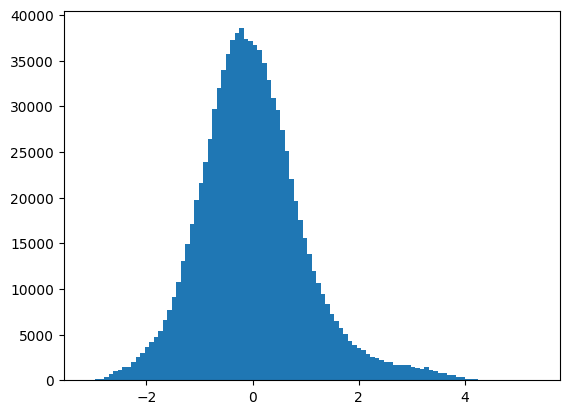

In [45]:
p = plt.hist(mom_scores["mom_score"].drop_nans(), bins = 100)
plt.show()

**Volume Factor**

In [63]:
volume_scores = factor_volume(volume_df=volume_df).collect()

shape: (5, 6)
┌─────────────────────┬────────┬──────────┬────────────┬───────────────┬───────────────┐
│ date                ┆ symbol ┆ volume   ┆ avg_volume ┆ vol_std       ┆ volume_zscore │
│ ---                 ┆ ---    ┆ ---      ┆ ---        ┆ ---           ┆ ---           │
│ datetime[μs]        ┆ str    ┆ f64      ┆ f64        ┆ f64           ┆ f64           │
╞═════════════════════╪════════╪══════════╪════════════╪═══════════════╪═══════════════╡
│ 2025-02-11 00:00:00 ┆ XYL    ┆ 1.2119e6 ┆ 1.46854e6  ┆ 485916.807261 ┆ -0.528156     │
│ 2025-02-11 00:00:00 ┆ YUM    ┆ 2.5418e6 ┆ 2.286025e6 ┆ 948755.464515 ┆ 0.26959       │
│ 2025-02-11 00:00:00 ┆ ZBH    ┆ 2.1018e6 ┆ 1.923005e6 ┆ 685586.128395 ┆ 0.260791      │
│ 2025-02-11 00:00:00 ┆ ZBRA   ┆ 951800.0 ┆ 512910.0   ┆ 279040.866466 ┆ 1.572852      │
│ 2025-02-11 00:00:00 ┆ ZTS    ┆ 2.3094e6 ┆ 2.66303e6  ┆ 824469.340721 ┆ -0.428918     │
└─────────────────────┴────────┴──────────┴────────────┴───────────────┴───────────────┘


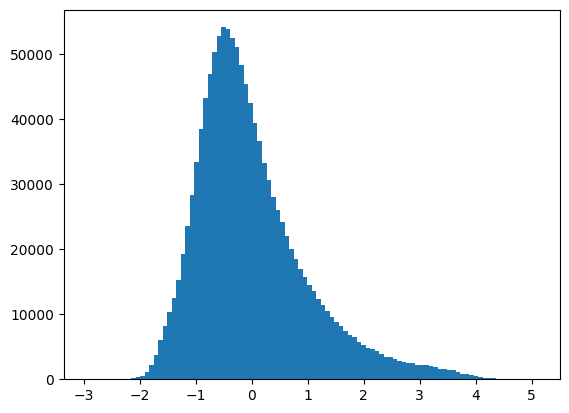

In [65]:
p = plt.hist(volume_scores["volume_zscore"].drop_nans(), bins = 100)
plt.show()